In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans  
from sklearn.model_selection import train_test_split

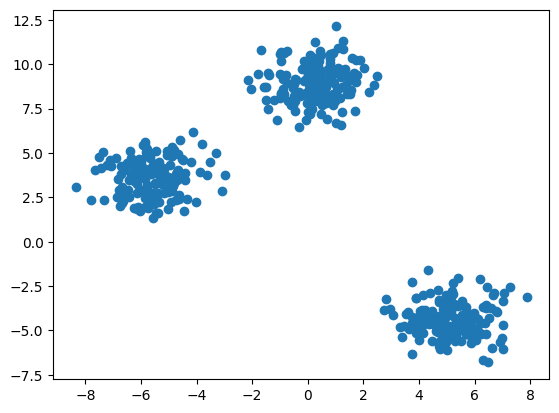

In [14]:
X,y = make_blobs(n_samples = 500,n_features = 2,centers = 3,random_state = 23)

fig = plt.figure(0)
plt.scatter(X[:,0],X[:,1])
plt.show()

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

Manual method to find the value of K

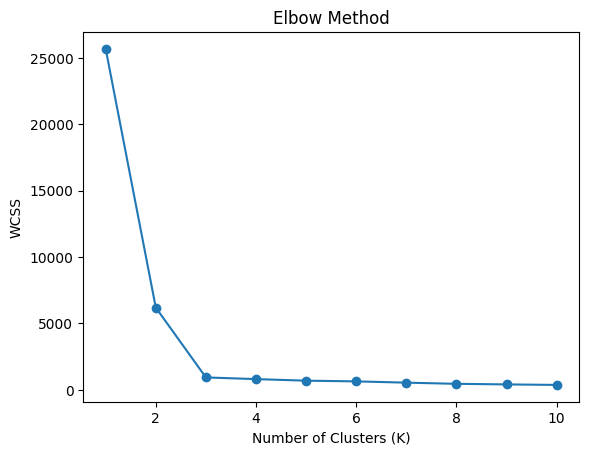

In [9]:
wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)  

plt.plot(range(1, 11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.show()

In [10]:
kmeans = KMeans(n_clusters=3,init='k-means++',random_state=42)
y_labels = kmeans.fit_predict(X_train)

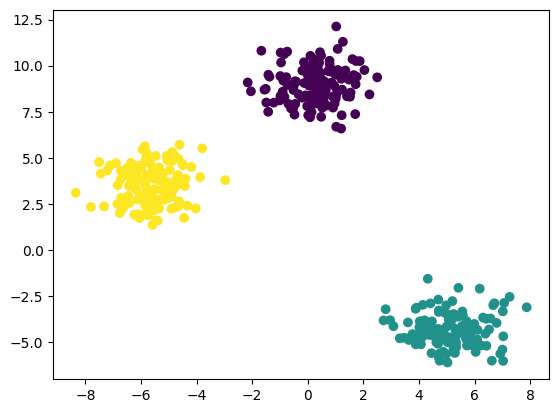

In [15]:
fig = plt.figure(0)
plt.scatter(X_train[:,0],X_train[:,1],c=y_labels)
plt.show()

Silhouette Coefficient

It measures how well a data point fits in its cluster.

S close to 1 → well clustered
S close to 0 → not clear clusters
S negative → wrongly assigned

K = 2, Silhouette Score = 0.723
K = 3, Silhouette Score = 0.812
K = 4, Silhouette Score = 0.672
K = 5, Silhouette Score = 0.529
K = 6, Silhouette Score = 0.528
K = 7, Silhouette Score = 0.345
K = 8, Silhouette Score = 0.362
K = 9, Silhouette Score = 0.345


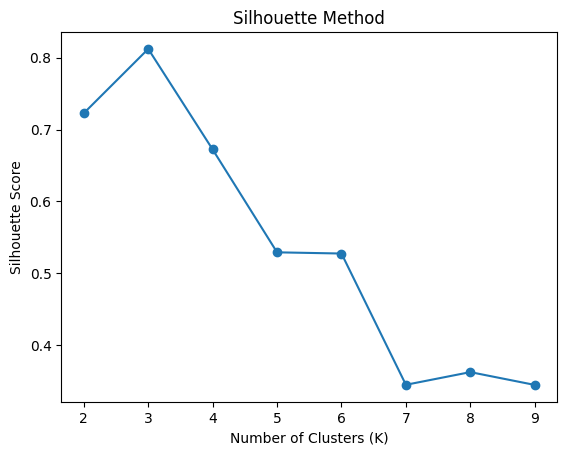

In [17]:
from sklearn.metrics import silhouette_score

sil_scores = []
K = range(2, 10)   

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X)
    
    score = silhouette_score(X, labels)
    sil_scores.append(score)

for k, score in zip(K, sil_scores):
    print(f"K = {k}, Silhouette Score = {score:.3f}")

plt.plot(K, sil_scores, marker='o')
plt.title("Silhouette Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.show()

final train the model after getting best K value

In [20]:
kmeans = KMeans(n_clusters=3, random_state=42)
labels = kmeans.fit_predict(X)

In [ ]:
centroids = kmeans.cluster_centers_
print(centroids)

[[ 0.293089    8.93255251]
 [ 5.1482619  -4.38609379]
 [-5.64869015  3.64917816]]


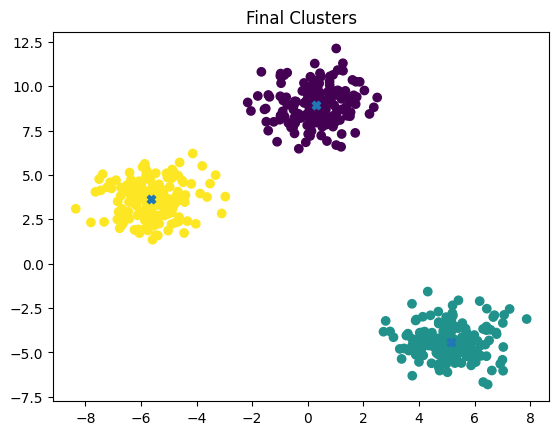

In [22]:
plt.scatter(X[:, 0], X[:, 1], c=labels)
plt.scatter(centroids[:, 0], centroids[:, 1], marker='X')
plt.title("Final Clusters")
plt.show()